In [2]:
import pandas as pd
from CosinorPy import file_parser, cosinor, cosinor1
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)
unusable_samples = [
    "A2450525897_n01_LICRNA01_A06",
    "A2450525897_n01_LICRNA01_A08",
    "A2450525897_n01_LICRNA01_C11",
    "A2450525897_n01_LICRNA01_D11",
    "A2450525897_n01_LICRNA01_D12",
    "A2449446903_n01_LICRNA02_F01",
    "B2449500127_n01_LICRNA04_A04",
    "B2449500127_n01_LICRNA04_A06",
    "B2449500127_n01_LICRNA04_A07",
]
borderline_unusable = [
    "A2450525897_n01_LICRNA01_F03",
    "A2450525897_n01_LICRNA01_G07",
    "A2449446903_n01_LICRNA02_A04",
    "A2449446903_n01_LICRNA02_H10",
    "B2449500127_n01_LICRNA04_H02",
    "B2449500127_n01_LICRNA04_H11",
]
all_unsable = borderline_unusable + unusable_samples
# trimmed_transcriptome = transcriptome.drop(index=all_unsable)
# trimmed_metadata = metadata.drop(index=all_unsable)
## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### get duplicates and drop the one with higher total genes, so that we can drop everything from the main list
double_duplicates = (
    trimmed_metadata.loc[
        trimmed_metadata.duplicated(
            subset="sampID",
            keep=False,
        )
    ]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_metadata
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
trimmed_transcriptome

defense_gene_list = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/load_correlated_defense_genes_union_GO_and_FLG.csv"
)

In [4]:
arabi_go_matrix = pd.read_csv(
    "/Users/michael/Data/Reference_data/Arabdidopsis_go_matrix_from_tair_gaf.csv",
    index_col=0,
)
arabi_go_matrix
defense_terms = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Defense_go_terms.csv"
)

In [4]:
defense_terms

,GO Term ID,GO Term Description,Note
0,GO:0012501,programmed cell death,NaN
1,GO:0009626,Plant type hypersensitive response,NaN
2,GO:0042742,defense response to bacterium,NaN
3,GO:0071219,cellular response to molecule of bacterial origin,NaN
4,GO:0045087,innate immune response,NaN
5,GO:0009862,"systemic acquired resistance, salicylic acid m...",NaN
6,GO:0009861,jasmonic acid and ethylene-dependent systemic ...,NaN
7,GO:0034055,effector-mediated activation of host programme...,not enough genes
8,GO:0009682,induced systemic resistance,NaN
9,GO:0009626,plant-type hypersensitive response,NaN


In [5]:
luke_defense_genes = [
    "AT1G02920",
    "AT1G02930",
    "AT1G21110",
    "AT1G21120",
    "AT1G26380",
    "AT1G26410",
    "AT1G26420",
    "AT1G35230",
    "AT1G64170",
    "AT1G65500",
    "AT1G76930",
    "AT2G19190",
    "AT2G25470",
    "AT2G30750",
    "AT2G39200",
    "AT2G43620",
    "AT3G46280",
    "AT4G12490",
    "AT4G12500",
    "AT4G23140",
    "AT4G23220",
    "AT4G28420",
    "AT5G24110",
    "AT5G64120",
]

In [6]:
go_terms = defense_terms["GO Term ID"].unique()
only_defense_terms = arabi_go_matrix.loc[:, arabi_go_matrix.columns.isin(go_terms)]
full_defense_gene_list = only_defense_terms.loc[
    only_defense_terms.any(axis="columns")
].index.to_list()
print(len(full_defense_gene_list))
full_defense_gene_list = list(set(full_defense_gene_list) | set(luke_defense_genes))
print(len(full_defense_gene_list))

658
663


In [7]:
circadian_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 1")
]
circadian_transcriptome = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 1")
]
circadian_metadata["Time Since Start"] = (
    circadian_metadata["Date and Time"]
    - circadian_metadata.sort_values(by="Date and Time")["Date and Time"].iloc[0]
) / pd.Timedelta(hours=1)


circadian_metadata_2 = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 2")
]
circadian_transcriptome_2 = trimmed_transcriptome.loc[
    trimmed_metadata["Experiment Type"].str.contains("Circadian Experiment 2")
]
circadian_metadata_2["Time Since Start"] = (
    circadian_metadata_2["Date and Time"]
    - circadian_metadata_2.sort_values(by="Date and Time")["Date and Time"].iloc[0]
) / pd.Timedelta(hours=1)

/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_76341/272630936.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  circadian_metadata["Time Since Start"] = (
/var/folders/nk/6xkk9sgn1pz4ff1b36sfq3y40000gt/T/ipykernel_76341/272630936.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  circadian_metadata_2["Time Since Start"] = (


In [11]:
trimmed_circadian_transcriptome = circadian_transcriptome.merge(
    right=circadian_metadata[["timepoint", "Time Since Start"]],
    left_index=True,
    right_index=True,
)
trimmed_circadian_transcriptome = trimmed_circadian_transcriptome.set_index(
    "timepoint", append=False
)
trimmed_circadian_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085,Time Since Start
timepoint,,,,,,,,,,,,,,,,,,,,,
c1_t01,0.397484,3.914962,0.0,0.528310,3.953698,0.0,0.0,40.794727,0.0,1.797838,...,7.125035,0.000000,0.000000,0.0,0.0,0.308596,0.0,0.000000,0.271092,0.0
c1_t01,0.242429,4.428221,0.0,0.644440,3.014240,0.0,0.0,17.650893,0.0,1.824204,...,4.528588,5.683607,5.465007,0.0,0.0,1.114433,0.0,0.000000,1.240060,0.0
c1_t01,1.673381,6.023319,0.0,1.853456,2.654170,0.0,0.0,54.553650,0.0,0.495411,...,4.262576,0.000000,5.130271,0.0,0.0,0.061540,0.0,0.000000,3.423839,0.0
c1_t01,0.306973,2.902550,0.0,0.054401,2.195151,0.0,0.0,36.827954,0.0,0.060587,...,4.239898,0.000000,0.442881,0.0,0.0,0.406409,0.0,0.000000,2.763579,0.0
c1_t01,0.731436,8.981825,0.0,0.185176,3.511319,0.0,0.0,34.519120,0.0,0.360907,...,2.484234,0.000000,4.145698,0.0,0.0,0.640452,0.0,0.000000,0.213795,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c1_t13,0.000000,8.339930,0.0,7.860235,3.199519,0.0,0.0,39.201659,0.0,1.057777,...,4.602930,22.529946,1.333133,0.0,0.0,0.036247,0.0,4.867353,5.293749,48.0
c1_t09,0.000000,1.692107,0.0,1.577446,3.055581,0.0,0.0,29.564231,0.0,12.872063,...,6.899039,1.605254,3.951394,0.0,0.0,0.839348,0.0,0.000000,3.222183,32.0
c1_t04,0.641335,5.972190,0.0,1.641699,5.632121,0.0,0.0,48.940407,0.0,24.612749,...,7.502750,0.000000,1.799150,0.0,0.0,0.000000,0.0,0.000000,0.145801,12.0


In [12]:
trimmed_circadian_transcriptome_2 = circadian_transcriptome_2.merge(
    right=circadian_metadata_2[["timepoint", "Time Since Start"]],
    left_index=True,
    right_index=True,
)
trimmed_circadian_transcriptome_2 = trimmed_circadian_transcriptome_2.set_index(
    "timepoint", append=False
)
trimmed_circadian_transcriptome_2

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085,Time Since Start
timepoint,,,,,,,,,,,,,,,,,,,,,
c2_t01,0.369734,5.032079,0.0,2.293318,1.259021,0.0,0.0,23.750115,0.0,0.243247,...,0.279057,14.446995,2.667137,0.0,0.0,0.030216,0.0,0.0,3.025989,0.0
c2_t01,0.000000,7.451890,0.0,2.867837,1.926605,0.0,0.0,23.558990,0.0,0.380231,...,1.832069,0.000000,5.280899,0.0,0.0,0.094464,0.0,0.0,1.892027,0.0
c2_t01,0.629969,6.656039,0.0,0.651243,2.907280,0.0,0.0,31.338727,0.0,2.745762,...,2.615081,0.000000,5.301787,0.0,0.0,0.025742,0.0,0.0,0.644477,0.0
c2_t01,0.402656,7.895757,0.0,2.854316,5.222927,0.0,0.0,37.193012,0.0,8.245217,...,2.849112,0.000000,5.809265,0.0,0.0,0.888476,0.0,0.0,6.384911,0.0
c2_t01,0.304598,4.418313,0.0,1.214553,5.117861,0.0,0.0,46.119998,0.0,2.630170,...,4.827800,0.000000,3.295902,0.0,0.0,0.000000,0.0,0.0,0.623225,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
c2_t13,0.620785,7.781875,0.0,2.872592,3.449003,0.0,0.0,33.680234,0.0,0.000000,...,8.589862,11.319746,3.731784,0.0,0.0,0.710259,0.0,0.0,7.197594,48.0
c2_t13,0.000000,2.561732,0.0,2.535106,2.600397,0.0,0.0,37.505886,0.0,0.470562,...,13.418790,0.000000,3.931116,0.0,0.0,0.217111,0.0,0.0,3.205647,48.0
c2_t01,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.293215,...,25.564923,0.000000,4.286696,0.0,0.0,0.000000,0.0,0.0,64.440730,0.0


In [13]:
merged_by_timepoint_circadian_transcriptome = trimmed_circadian_transcriptome.groupby(
    "timepoint"
).mean()
merged_by_timepoint_circadian_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085,Time Since Start
timepoint,,,,,,,,,,,,,,,,,,,,,
c1_t01,0.537904,5.951338,0.0,1.940228,3.148396,0.0,0.000000,31.201111,0.000000,1.063178,...,5.116946,0.710451,3.043686,0.0,0.0,0.412291,0.0,0.000000,2.297625,0.0
c1_t02,1.476474,5.358225,0.0,1.498052,2.882145,0.0,0.239297,29.949714,0.000000,3.530612,...,5.335848,4.928663,4.365356,0.0,0.0,0.404082,0.0,0.000000,2.166721,4.0
c1_t03,1.153669,5.999800,0.0,1.812127,3.487374,0.0,0.000000,37.833377,0.000000,11.937175,...,3.832741,4.687911,3.201531,0.0,0.0,0.364968,0.0,0.000000,2.847598,8.0
c1_t04,0.559132,4.865199,0.0,2.088175,3.345267,0.0,0.000000,34.967377,0.000000,15.497050,...,4.446323,4.448165,3.433265,0.0,0.0,0.412008,0.0,0.000000,1.653954,12.0
c1_t05,0.771969,4.868313,0.0,1.280354,2.757246,0.0,0.000000,32.050421,0.000000,7.480780,...,6.461871,6.688622,5.253620,0.0,0.0,0.227474,0.0,0.237020,3.705129,16.0
c1_t06,0.512436,5.322230,0.0,1.395029,2.679409,0.0,0.000000,36.018233,0.033458,0.804330,...,5.094827,0.756887,2.786559,0.0,0.0,0.302136,0.0,0.000000,1.745792,20.0
c1_t07,0.752485,5.785683,0.0,1.186666,3.548397,0.0,0.000000,44.002670,0.000000,0.358735,...,4.974461,4.227200,2.223456,0.0,0.0,0.358217,0.0,0.186116,2.069895,24.0
c1_t08,0.660199,6.177843,0.0,1.426387,3.274844,0.0,0.000000,35.101527,0.000000,1.097545,...,5.653718,4.119020,4.715959,0.0,0.0,0.357451,0.0,0.438708,2.175584,28.0
c1_t09,1.054015,5.800128,0.0,1.418720,3.255234,0.0,0.000000,34.428704,0.000000,15.921169,...,4.666604,0.200657,2.095402,0.0,0.0,0.263480,0.0,0.000000,1.970292,32.0


In [14]:
cosinor_formatted_circadian_transcriptome = trimmed_circadian_transcriptome.melt(
    id_vars="Time Since Start", var_name="Gene", value_name="y"
)
cosinor_formatted_circadian_transcriptome = (
    cosinor_formatted_circadian_transcriptome.rename(
        columns={"Gene": "test", "Time Since Start": "x"}
    )
)
cosinor_formatted_circadian_transcriptome = cosinor_formatted_circadian_transcriptome[
    ["test", "x", "y"]
]
cosinor_formatted_circadian_transcriptome

,test,x,y
0,AT1G01010,0.0,0.397484
1,AT1G01010,0.0,0.242429
2,AT1G01010,0.0,1.673381
3,AT1G01010,0.0,0.306973
4,AT1G01010,0.0,0.731436
...,...,...,...
3982675,ArthCp085,48.0,5.293749
3982676,ArthCp085,32.0,3.222183
3982677,ArthCp085,12.0,0.145801
3982678,ArthCp085,32.0,3.821523


In [15]:
cosinor_formatted_circadian_transcriptome_2 = trimmed_circadian_transcriptome_2.melt(
    id_vars="Time Since Start", var_name="Gene", value_name="y"
)
cosinor_formatted_circadian_transcriptome_2 = (
    cosinor_formatted_circadian_transcriptome_2.rename(
        columns={"Gene": "test", "Time Since Start": "x"}
    )
)
cosinor_formatted_circadian_transcriptome_2 = (
    cosinor_formatted_circadian_transcriptome_2[["test", "x", "y"]]
)
cosinor_formatted_circadian_transcriptome_2

,test,x,y
0,AT1G01010,0.0,0.369734
1,AT1G01010,0.0,0.000000
2,AT1G01010,0.0,0.629969
3,AT1G01010,0.0,0.402656
4,AT1G01010,0.0,0.304598
...,...,...,...
3982675,ArthCp085,48.0,7.197594
3982676,ArthCp085,48.0,3.205647
3982677,ArthCp085,0.0,64.440730
3982678,ArthCp085,16.0,3.510440


In [16]:
cosinor_gene_results_2 = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Gene_cosine_results_circadian_experiment_2_more_genes.csv"
)

In [17]:
cosinor_gene_results = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Output_for_Luke/Gene_cosine_results_circadian_experiment_1_more_genes.csv"
)

In [18]:
cosinor_gene_results

,test,period,p,q,amplitude,p(amplitude),q(amplitude),CI(amplitude),acrophase,p(acrophase),q(acrophase),CI(acrophase),acrophase[h]
0,AT1G01010,24.0,0.030610,0.075153,0.304750,0.007246,0.017809,"[np.float64(0.08231761601465115), np.float64(0...",-1.818515,1.988479e-07,0.000001,"[np.float64(-2.5038884551704794), np.float64(-...",6.946216
1,AT1G01020,24.0,0.238275,0.353689,0.586045,0.088690,0.131580,"[np.float64(-0.08868511701801962), np.float64(...",-1.021486,7.243576e-02,0.132849,"[np.float64(-2.135998950246445), np.float64(0....",3.901791
2,AT1G01030,24.0,0.487253,0.595060,0.275275,0.229475,0.280287,"[np.float64(-0.17369128570149883), np.float64(...",-2.721103,1.822102e-03,0.005077,"[np.float64(-4.431691406310053), np.float64(-1...",10.393846
3,AT1G01040,24.0,0.615459,0.703253,0.216200,0.323327,0.369620,"[np.float64(-0.21284555721290419), np.float64(...",-1.545620,1.010884e-01,0.176070,"[np.float64(-3.3932402642839676), np.float64(0...",5.903832
4,AT1G01050,24.0,0.527534,0.630539,1.667916,0.256990,0.307238,"[np.float64(-1.2160351491113726), np.float64(4...",1.888379,2.336770e-02,0.050332,"[np.float64(0.256022226993742), np.float64(3.5...",16.786924
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17233,ArthCt124,24.0,0.437745,0.550431,1.003385,0.196830,0.247544,"[np.float64(-0.520358399861591), np.float64(2....",-3.092340,2.017680e-04,0.000670,"[np.float64(-4.723013535374932), np.float64(-1...",11.811869
17234,ArthCr088,24.0,0.983939,0.988123,0.080335,0.857185,0.860830,"[np.float64(-0.7946092780222602), np.float64(0...",0.067684,9.909469e-01,0.994531,"[np.float64(-11.62364521056486), np.float64(11...",23.741468
17235,ArthCt112,24.0,0.883223,0.916175,0.422995,0.618020,0.641116,"[np.float64(-1.2395749960550184), np.float64(2...",-3.131002,1.460804e-01,0.239568,"[np.float64(-7.352936023155259), np.float64(1....",11.959546
17236,ArthCp088,24.0,0.213587,0.327127,0.718297,0.076878,0.117776,"[np.float64(-0.07749652534499762), np.float64(...",-2.832559,2.274418e-06,0.000010,"[np.float64(-4.006934921937825), np.float64(-1...",10.819579


In [48]:
defense_gene_list

,gene
0,AT1G01100
1,AT1G01230
2,AT1G04510
3,AT1G07360
4,AT1G08450
...,...
194,AT5G64810
195,AT5G65200
196,AT5G67300
197,AT5G67330


In [49]:
circ_1_results = cosinor_gene_results.loc[
    cosinor_gene_results["test"].isin(defense_gene_list["gene"])
][["test", "p", "amplitude", "acrophase", "acrophase[h]"]]


circ_2_results = cosinor_gene_results_2.loc[
    cosinor_gene_results_2["test"].isin(defense_gene_list["gene"])
][["test", "p", "amplitude", "acrophase", "acrophase[h]"]]

circ_2_results = circ_2_results.rename(
    columns={
        "amplitude": "amplitude_2",
        "acrophase": "acrophase_2",
        "p": "p_2",
        "acrophase[h]": "acrophase_2[h]",
    },
)

In [50]:
circ_1_results

,test,p,amplitude,acrophase,acrophase[h]
9,AT1G01100,0.923110,8.640992,1.389628,18.692014
22,AT1G01230,0.162148,1.802583,-0.720695,2.752852
264,AT1G04510,0.023725,2.033988,-2.798760,10.690477
466,AT1G07360,0.031325,2.254747,-1.531530,5.850014
553,AT1G08450,0.000311,6.548918,-1.520350,5.807308
...,...,...,...,...,...
16872,AT5G64810,0.065054,1.004552,-1.191422,4.550898
16903,AT5G65200,0.056074,0.429019,-0.529258,2.021618
17073,AT5G67300,0.030963,3.391299,0.929511,20.449529
17075,AT5G67330,0.108075,0.903208,0.344773,22.683064


In [51]:
merged_results_present_both_samples = circ_1_results.merge(
    right=circ_2_results,
    left_on="test",
    right_on="test",
    how="inner",
)
merged_results_present_both_samples

,test,p,amplitude,acrophase,acrophase[h],p_2,amplitude_2,acrophase_2,acrophase_2[h]
0,AT1G01100,0.923110,8.640992,1.389628,18.692014,0.001340,110.563252,-0.971575,3.711144
1,AT1G01230,0.162148,1.802583,-0.720695,2.752852,0.036554,4.160098,-1.234634,4.715953
2,AT1G04510,0.023725,2.033988,-2.798760,10.690477,0.007475,13.036483,-1.305189,4.985455
3,AT1G07360,0.031325,2.254747,-1.531530,5.850014,0.153469,5.549887,-1.347641,5.147609
4,AT1G08450,0.000311,6.548918,-1.520350,5.807308,0.002796,15.733476,-0.493126,1.883601
...,...,...,...,...,...,...,...,...,...
187,AT5G64810,0.065054,1.004552,-1.191422,4.550898,0.177863,2.047707,-0.570574,2.179432
188,AT5G65200,0.056074,0.429019,-0.529258,2.021618,0.826036,0.104637,-1.676820,6.404982
189,AT5G67300,0.030963,3.391299,0.929511,20.449529,0.004946,4.663551,-1.703556,6.507104
190,AT5G67330,0.108075,0.903208,0.344773,22.683064,0.202238,1.059652,-1.223199,4.672278


In [60]:
merged_results_present_both_samples = merged_results_present_both_samples.loc[
    merged_results_present_both_samples["p"] < 1e-6
]
merged_results_present_both_samples
merged_results_present_both_samples["Delta Amplitude"] = (
    merged_results_present_both_samples["amplitude"]
    - merged_results_present_both_samples["amplitude_2"]
)

In [61]:
merged_results_present_both_samples

,test,p,amplitude,acrophase,acrophase[h],p_2,amplitude_2,acrophase_2,acrophase_2[h],Delta Amplitude
12,AT1G22885,1.955813e-09,17.873090,-1.511684,5.774209,2.550484e-01,6.307221,-0.658024,2.513465,11.565869
14,AT1G25275,1.242004e-14,237.337766,-0.853293,3.259341,1.424195e-06,423.017075,-0.463628,1.770929,-185.679309
22,AT1G33970,9.544894e-09,1.622665,0.672822,21.430009,4.928003e-02,0.754828,0.958264,20.339700,0.867837
43,AT2G03440,7.232597e-07,26.756666,0.279466,22.932517,5.552895e-03,19.646080,1.257116,19.198171,7.110586
56,AT2G27050,5.590524e-08,2.604745,-0.716895,2.738339,4.462415e-02,2.093655,-0.911316,3.480970,0.511091
59,AT2G32800,6.888548e-07,1.090747,-0.739907,2.826237,1.720755e-02,0.904902,-0.872634,3.333218,0.185845
63,AT2G36750,6.451873e-11,2.612333,1.716369,17.443955,5.971529e-01,0.437843,2.503742,14.436409,2.174490
70,AT2G43710,3.237184e-12,19.624511,3.022350,12.455474,1.378773e-08,22.770427,-2.202751,8.413889,-3.145916
72,AT2G44490,7.019442e-08,14.861016,0.385361,22.528029,6.519786e-05,12.845715,1.100765,19.795388,2.015301
98,AT3G49780,1.210186e-08,8.070202,-1.009992,3.857883,1.558525e-04,20.082709,-0.871816,3.330091,-12.012507


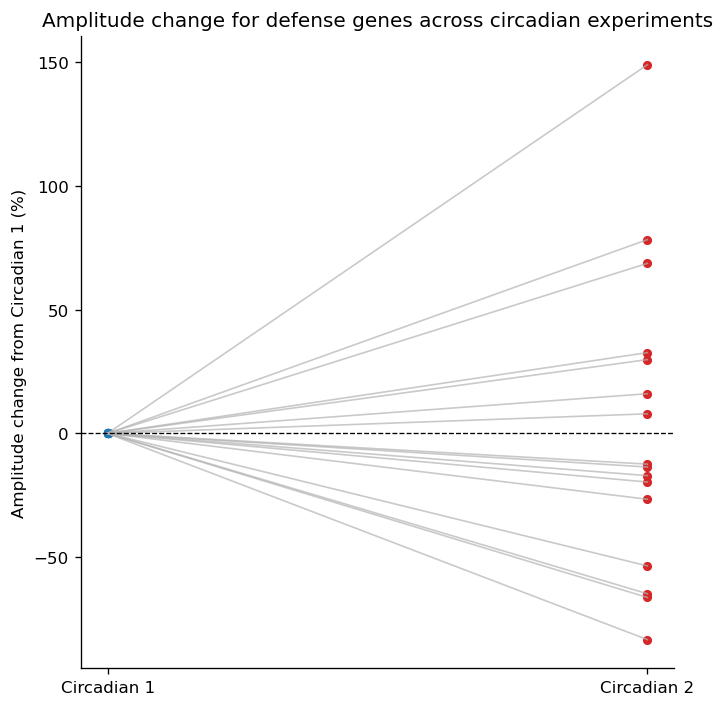

In [59]:
paired_amplitude_plot_data = (
    merged_results_present_both_samples[["test", "amplitude", "amplitude_2"]]
    .dropna()
    .loc[lambda df: df["amplitude"] > 0]
    .copy()
)

paired_amplitude_plot_data["amplitude_change_percent"] = 0.0
paired_amplitude_plot_data["amplitude_2_change_percent"] = (
    (
        paired_amplitude_plot_data["amplitude_2"]
        - paired_amplitude_plot_data["amplitude"]
    )
    / paired_amplitude_plot_data["amplitude"]
    * 100
)
paired_amplitude_plot_data = paired_amplitude_plot_data.sort_values(
    by="amplitude_2_change_percent"
)

fig, ax = plt.subplots(
    figsize=(6, max(6, len(paired_amplitude_plot_data) * 0.18)), dpi=120
)

for row in paired_amplitude_plot_data.itertuples(index=False):
    ax.plot(
        [0, 1],
        [row.amplitude_change_percent, row.amplitude_2_change_percent],
        color="0.7",
        alpha=0.7,
        linewidth=1,
    )
    ax.scatter(0, row.amplitude_change_percent, color="#1f77b4", s=20)
    ax.scatter(1, row.amplitude_2_change_percent, color="#d62728", s=20)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks([0, 1], ["Circadian 1", "Circadian 2"])
ax.set_ylabel("Amplitude change from Circadian 1 (%)")
ax.set_title("Amplitude change for defense genes across circadian experiments")

sns.despine()
plt.tight_layout()
plt.show()

In [67]:
paired_amplitude_plot_data["amplitude_2_change_percent"].median()

np.float64(-12.982262761571466)

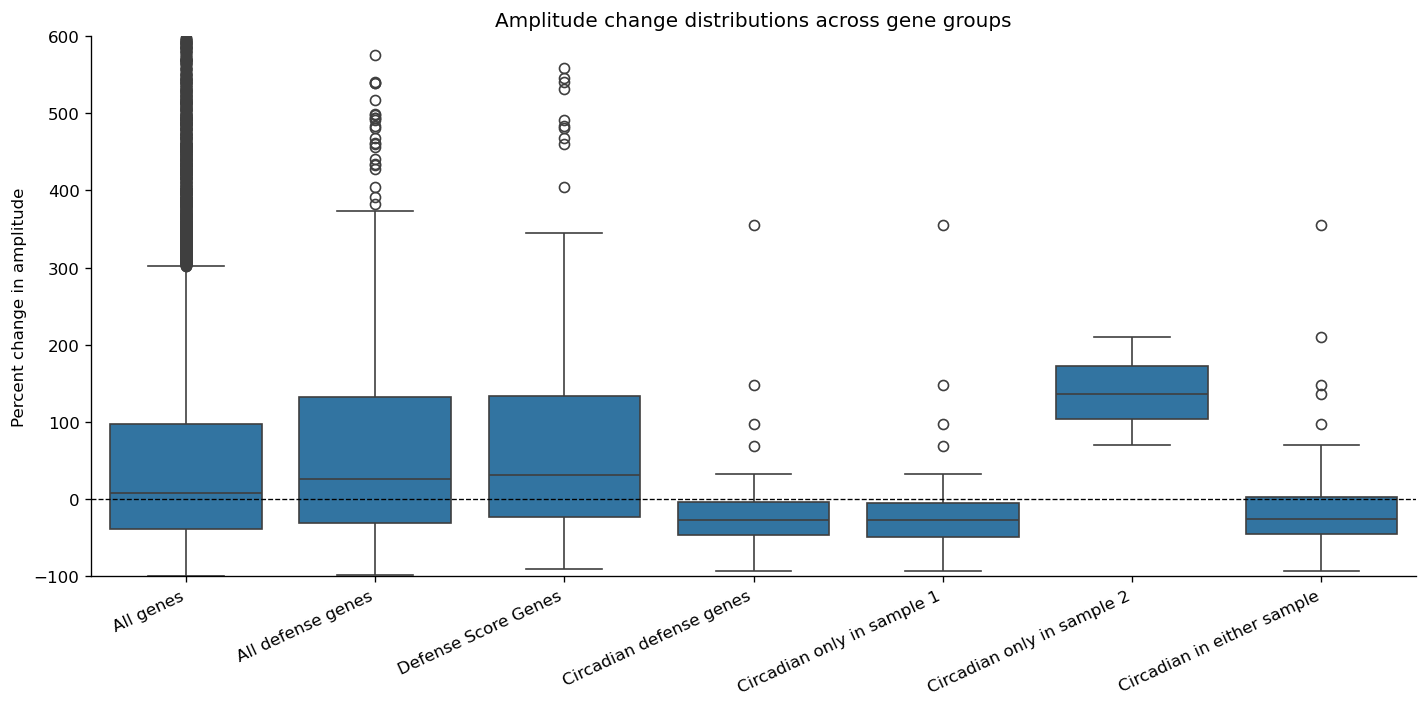

In [73]:
all_circ_1_results = cosinor_gene_results[["test", "p", "amplitude"]]

all_circ_2_results = cosinor_gene_results_2[["test", "p", "amplitude"]].rename(
    columns={"p": "p_2", "amplitude": "amplitude_2"}
)

merged_all_gene_results = all_circ_1_results.merge(
    all_circ_2_results, on="test", how="inner"
)
merged_all_gene_results = merged_all_gene_results.loc[
    merged_all_gene_results["amplitude"] > 0
].copy()
merged_all_gene_results["percent_change_in_amplitude"] = (
    (merged_all_gene_results["amplitude_2"] - merged_all_gene_results["amplitude"])
    / merged_all_gene_results["amplitude"]
    * 100
)

circadian_threshold = 1e-6
defense_mask = merged_all_gene_results["test"].isin(full_defense_gene_list)
defense_score_mask = merged_all_gene_results["test"].isin(defense_gene_list["gene"])
sample1_circadian_mask = merged_all_gene_results["p"] < circadian_threshold
sample2_circadian_mask = merged_all_gene_results["p_2"] < circadian_threshold

group_order = [
    "All genes",
    "All defense genes",
    "Defense Score Genes",
    "Circadian defense genes",
    "Circadian only in sample 1",
    "Circadian only in sample 2",
    "Circadian in either sample",
]

violin_plot_data = pd.concat(
    [
        merged_all_gene_results[["test", "percent_change_in_amplitude"]].assign(
            Group="All genes"
        ),
        merged_all_gene_results.loc[
            defense_mask,
            ["test", "percent_change_in_amplitude"],
        ].assign(Group="All defense genes"),
        merged_all_gene_results.loc[
            defense_score_mask,
            ["test", "percent_change_in_amplitude"],
        ].assign(Group="Defense Score Genes"),
        merged_all_gene_results.loc[
            defense_mask & sample1_circadian_mask,
            ["test", "percent_change_in_amplitude"],
        ].assign(Group="Circadian defense genes"),
        merged_all_gene_results.loc[
            defense_mask & sample1_circadian_mask & ~sample2_circadian_mask,
            ["test", "percent_change_in_amplitude"],
        ].assign(Group="Circadian only in sample 1"),
        merged_all_gene_results.loc[
            defense_mask & ~sample1_circadian_mask & sample2_circadian_mask,
            ["test", "percent_change_in_amplitude"],
        ].assign(Group="Circadian only in sample 2"),
        merged_all_gene_results.loc[
            defense_mask & (sample1_circadian_mask | sample2_circadian_mask),
            ["test", "percent_change_in_amplitude"],
        ].assign(Group="Circadian in either sample"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
sns.boxplot(
    data=violin_plot_data,
    x="Group",
    y="percent_change_in_amplitude",
    order=group_order,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Percent change in amplitude")
ax.set_xlabel("")
ax.set_title("Amplitude change distributions across gene groups")
plt.xticks(rotation=25, ha="right")
plt.ylim(-100, 600)
sns.despine()
plt.tight_layout()
plt.show()

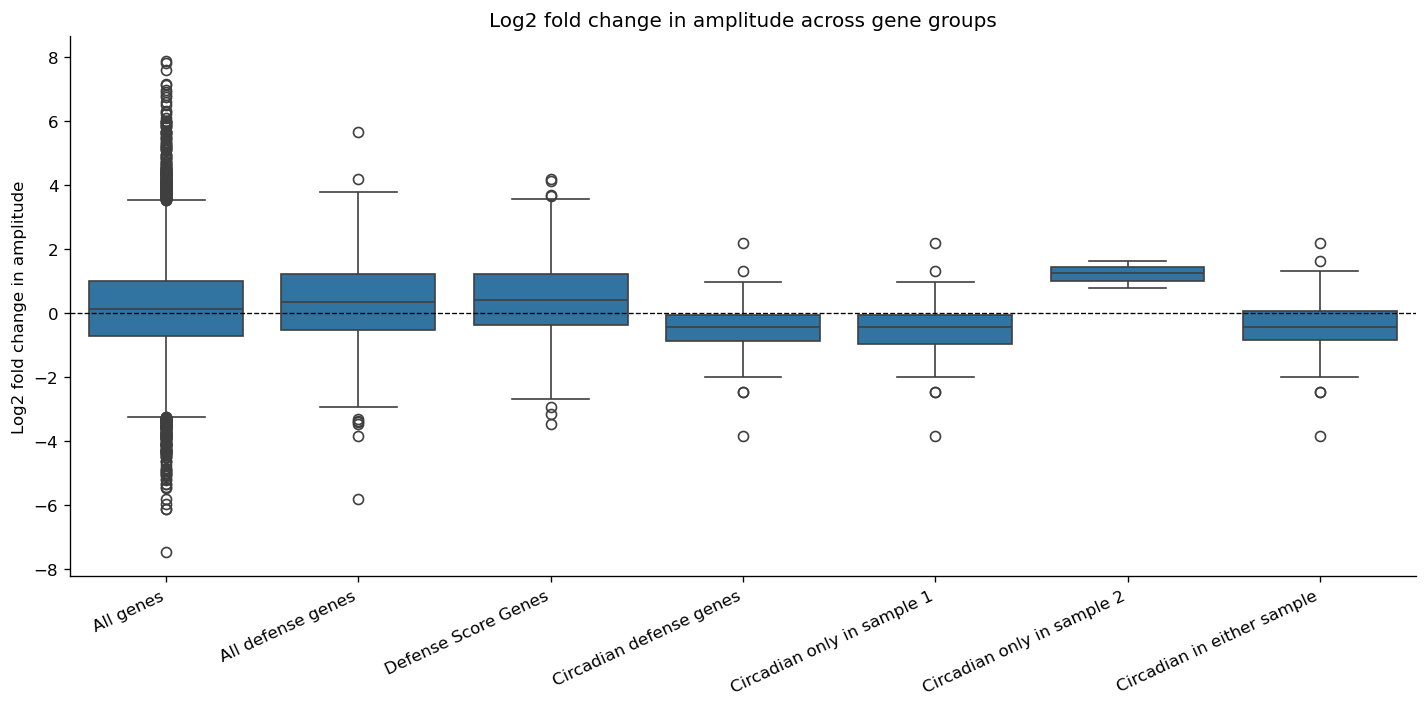

In [74]:
log2_merged_all_gene_results = all_circ_1_results.merge(
    all_circ_2_results, on="test", how="inner"
)
log2_merged_all_gene_results = log2_merged_all_gene_results.loc[
    (log2_merged_all_gene_results["amplitude"] > 0)
    & (log2_merged_all_gene_results["amplitude_2"] > 0)
].copy()
log2_merged_all_gene_results["log2_fold_change_in_amplitude"] = np.log2(
    log2_merged_all_gene_results["amplitude_2"]
    / log2_merged_all_gene_results["amplitude"]
)

circadian_threshold = 1e-6
log2_defense_mask = log2_merged_all_gene_results["test"].isin(full_defense_gene_list)
log2_defense_score_mask = log2_merged_all_gene_results["test"].isin(
    defense_gene_list["gene"]
)
log2_sample1_circadian_mask = log2_merged_all_gene_results["p"] < circadian_threshold
log2_sample2_circadian_mask = log2_merged_all_gene_results["p_2"] < circadian_threshold

log2_group_order = [
    "All genes",
    "All defense genes",
    "Defense Score Genes",
    "Circadian defense genes",
    "Circadian only in sample 1",
    "Circadian only in sample 2",
    "Circadian in either sample",
]

log2_boxplot_data = pd.concat(
    [
        log2_merged_all_gene_results[["test", "log2_fold_change_in_amplitude"]].assign(
            Group="All genes"
        ),
        log2_merged_all_gene_results.loc[
            log2_defense_mask,
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="All defense genes"),
        log2_merged_all_gene_results.loc[
            log2_defense_score_mask,
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="Defense Score Genes"),
        log2_merged_all_gene_results.loc[
            log2_defense_mask & log2_sample1_circadian_mask,
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="Circadian defense genes"),
        log2_merged_all_gene_results.loc[
            log2_defense_mask
            & log2_sample1_circadian_mask
            & ~log2_sample2_circadian_mask,
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="Circadian only in sample 1"),
        log2_merged_all_gene_results.loc[
            log2_defense_mask
            & ~log2_sample1_circadian_mask
            & log2_sample2_circadian_mask,
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="Circadian only in sample 2"),
        log2_merged_all_gene_results.loc[
            log2_defense_mask
            & (log2_sample1_circadian_mask | log2_sample2_circadian_mask),
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="Circadian in either sample"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
sns.boxplot(
    data=log2_boxplot_data,
    x="Group",
    y="log2_fold_change_in_amplitude",
    order=log2_group_order,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Log2 fold change in amplitude")
ax.set_xlabel("")
ax.set_title("Log2 fold change in amplitude across gene groups")
plt.xticks(rotation=25, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

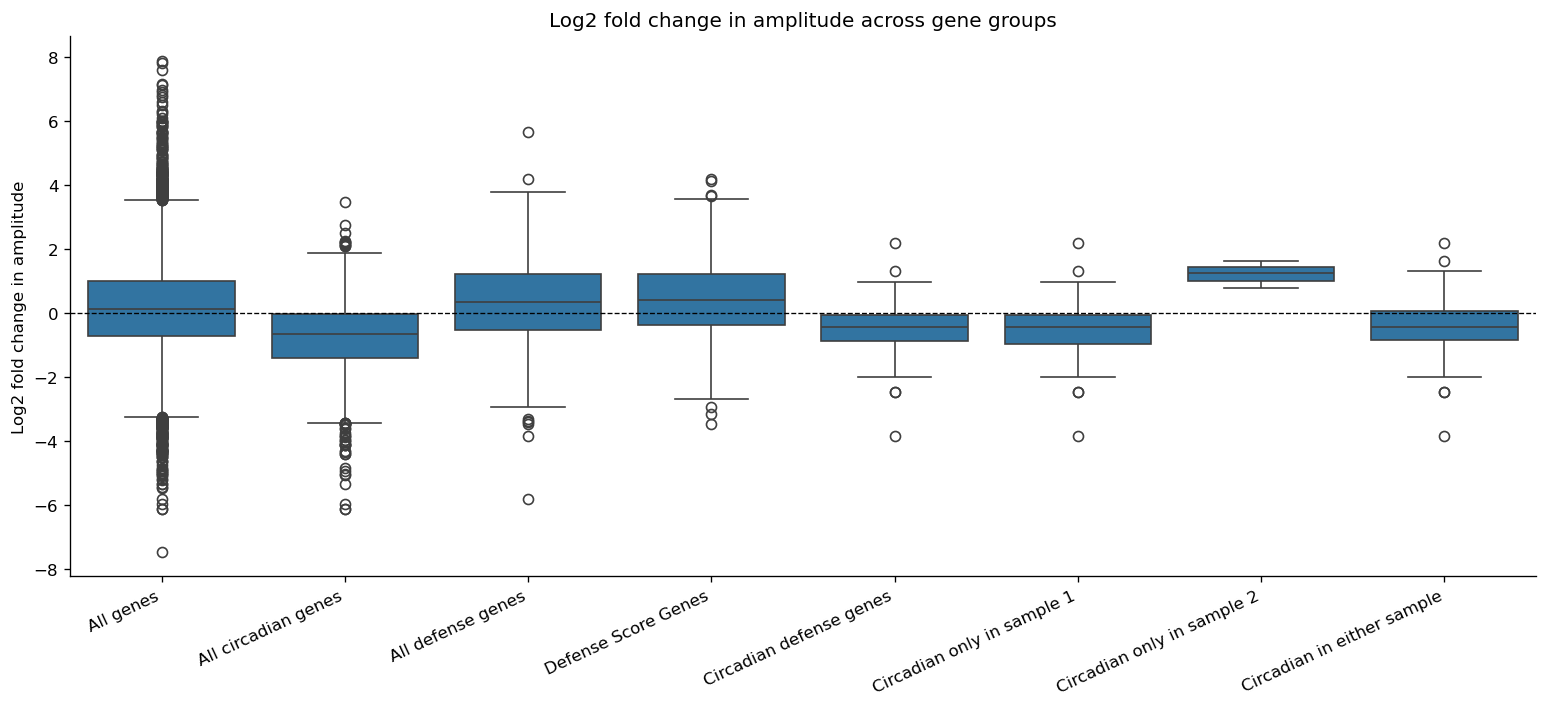

In [75]:
log2_merged_all_gene_results = all_circ_1_results.merge(
    all_circ_2_results, on="test", how="inner"
)
log2_merged_all_gene_results = log2_merged_all_gene_results.loc[
    (log2_merged_all_gene_results["amplitude"] > 0)
    & (log2_merged_all_gene_results["amplitude_2"] > 0)
].copy()
log2_merged_all_gene_results["log2_fold_change_in_amplitude"] = np.log2(
    log2_merged_all_gene_results["amplitude_2"]
    / log2_merged_all_gene_results["amplitude"]
)

circadian_threshold = 1e-6
log2_defense_mask = log2_merged_all_gene_results["test"].isin(full_defense_gene_list)
log2_defense_score_mask = log2_merged_all_gene_results["test"].isin(
    defense_gene_list["gene"]
)
log2_sample1_circadian_mask = log2_merged_all_gene_results["p"] < circadian_threshold
log2_sample2_circadian_mask = log2_merged_all_gene_results["p_2"] < circadian_threshold

log2_group_order = [
    "All genes",
    "All circadian genes",
    "All defense genes",
    "Defense Score Genes",
    "Circadian defense genes",
    "Circadian only in sample 1",
    "Circadian only in sample 2",
    "Circadian in either sample",
]

log2_boxplot_data = pd.concat(
    [
        log2_merged_all_gene_results[["test", "log2_fold_change_in_amplitude"]].assign(
            Group="All genes"
        ),
        log2_merged_all_gene_results.loc[
            log2_sample1_circadian_mask,
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="All circadian genes"),
        log2_merged_all_gene_results.loc[
            log2_defense_mask,
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="All defense genes"),
        log2_merged_all_gene_results.loc[
            log2_defense_score_mask,
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="Defense Score Genes"),
        log2_merged_all_gene_results.loc[
            log2_defense_mask & log2_sample1_circadian_mask,
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="Circadian defense genes"),
        log2_merged_all_gene_results.loc[
            log2_defense_mask
            & log2_sample1_circadian_mask
            & ~log2_sample2_circadian_mask,
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="Circadian only in sample 1"),
        log2_merged_all_gene_results.loc[
            log2_defense_mask
            & ~log2_sample1_circadian_mask
            & log2_sample2_circadian_mask,
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="Circadian only in sample 2"),
        log2_merged_all_gene_results.loc[
            log2_defense_mask
            & (log2_sample1_circadian_mask | log2_sample2_circadian_mask),
            ["test", "log2_fold_change_in_amplitude"],
        ].assign(Group="Circadian in either sample"),
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(13, 6), dpi=120)
sns.boxplot(
    data=log2_boxplot_data,
    x="Group",
    y="log2_fold_change_in_amplitude",
    order=log2_group_order,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("Log2 fold change in amplitude")
ax.set_xlabel("")
ax.set_title("Log2 fold change in amplitude across gene groups")
plt.xticks(rotation=25, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

In [41]:
merged_results_present_both_samples[
    (
        merged_results_present_both_samples["p"]
        + merged_results_present_both_samples["p_2"]
    )
    < 0.001
]

,test,p,amplitude,acrophase,acrophase[h],p_2,amplitude_2,acrophase_2,acrophase_2[h]
69,AT1G31350,7.139903e-05,4.628733,-0.956747,3.654506,3.514651e-08,7.890107,-0.971471,3.710745
70,AT1G31580,8.448219e-05,3.022709,0.412825,22.423124,2.937202e-04,4.900560,0.546861,21.911145
91,AT1G52740,2.322286e-04,26.998223,-1.225069,4.679419,1.457119e-06,110.964425,-1.243429,4.749549
98,AT1G59870,3.918946e-06,14.445159,-0.813048,3.105616,3.878693e-04,23.396066,0.534950,21.956641
111,AT1G65490,1.211496e-13,132.834853,-2.811899,10.740663,2.910055e-08,137.138732,-2.326796,8.887706
113,AT1G65930,6.231076e-17,103.703080,-2.099149,8.018159,2.204679e-04,80.536390,-1.054562,4.028129
116,AT1G66730,3.338934e-11,1.278544,2.939995,12.770045,5.164504e-04,0.885106,-2.770102,10.581010
178,AT2G26440,7.120005e-04,2.981696,0.471933,22.197349,2.700807e-04,7.906163,0.832182,20.821300
187,AT2G29630,9.545808e-09,17.814373,0.391372,22.505068,8.078548e-04,8.535727,1.048607,19.994615
196,AT2G33830,1.294817e-17,352.569519,0.550504,21.897231,2.192528e-08,297.026576,0.820510,20.865882


<Axes: xlabel='amplitude', ylabel='Count'>

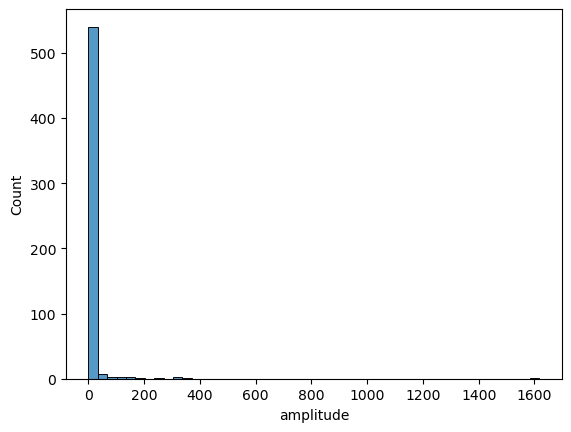

In [23]:
sns.histplot(
    cosinor_gene_results.loc[cosinor_gene_results["test"].isin(full_defense_gene_list)][
        "amplitude"
    ]
)

In [ ]:
def plot_single_gene_cosinor(gene_name):
    single_gene_data = cosinor_formatted_circadian_transcriptome.loc[
        cosinor_formatted_circadian_transcriptome["test"] == gene_name
    ]
    results = cosinor1.fit_group(single_gene_data, period=[24], plot_on=True)
    print(results)

In [ ]:
cosinor_gene_results.sort_values(by="q").head(20)

NameError: name 'cosinor_gene_results' is not defined

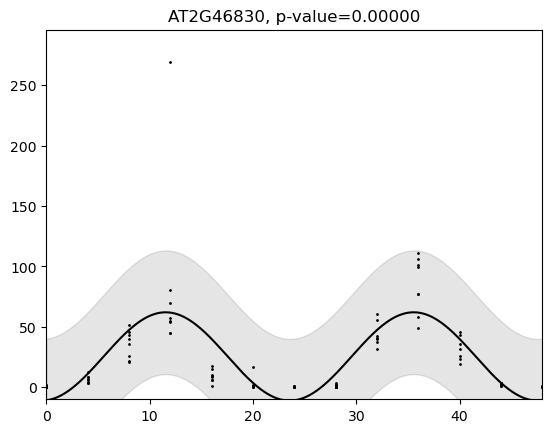

        test  period             p             q  amplitude  p(amplitude)  \
0  AT2G46830    24.0  2.225084e-17  2.225084e-17  36.555938  3.267348e-26   

   q(amplitude)                            CI(amplitude)  acrophase  \
0  3.267348e-26  [29.791162334579816, 43.32071462144045]  -3.022966   

    p(acrophase)   q(acrophase)                            CI(acrophase)  \
0  9.995344e-218  9.995344e-218  [-3.21108433154816, -2.834846804575057]   

   acrophase[h]  
0     11.546878  


In [ ]:
plot_single_gene_cosinor("AT2G46830")

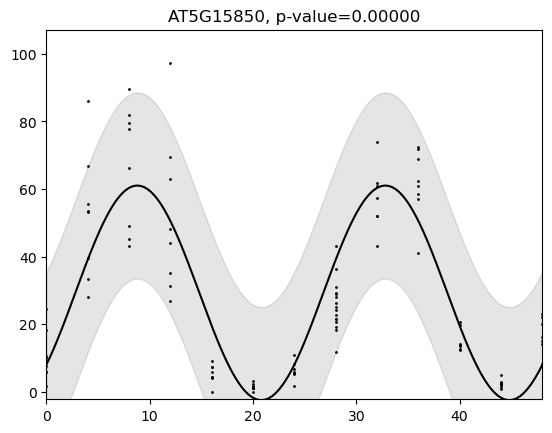

        test  period             p             q  amplitude  p(amplitude)  \
0  AT5G15850    24.0  4.821548e-30  4.821548e-30  31.724396  2.952672e-61   

   q(amplitude)                             CI(amplitude)  acrophase  \
0  2.952672e-61  [27.958983663884034, 35.489809119243446]  -2.305139   

   p(acrophase)  q(acrophase)                               CI(acrophase)  \
0           0.0           0.0  [-2.4176885857544996, -2.1925894293528647]   

   acrophase[h]  
0      8.804982  


In [ ]:
plot_single_gene_cosinor("AT5G15850")

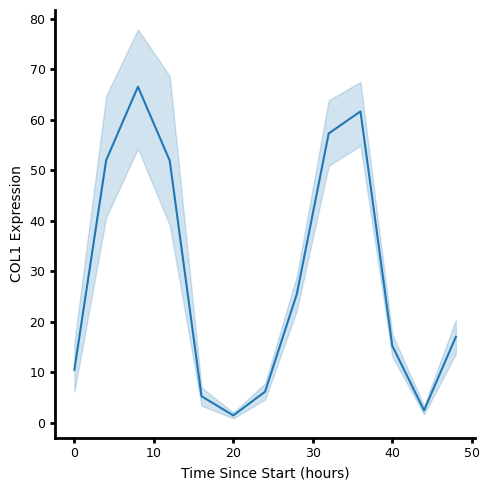

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

at5g15850_plot_data = pd.DataFrame(
    {
        "Time Since Start": circadian_metadata["Time Since Start"],
        "AT5G15850": circadian_transcriptome["AT5G15850"],
    }
).sort_values("Time Since Start")

fig, ax = plt.subplots(figsize=(5, 5), dpi=100)
fig.patch.set_facecolor("white")
sns.lineplot(
    data=at5g15850_plot_data,
    x="Time Since Start",
    y="AT5G15850",
    errorbar=("ci", 95),
    color="#1f77b4",
    ax=ax,
    sort=True,
    estimator="mean",
)
plt.ylabel("COL1 Expression", fontsize=10)
plt.xlabel("Time Since Start (hours)", fontsize=10)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.spines["top"].set_color("black")
ax.spines["top"].set_linewidth(0)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

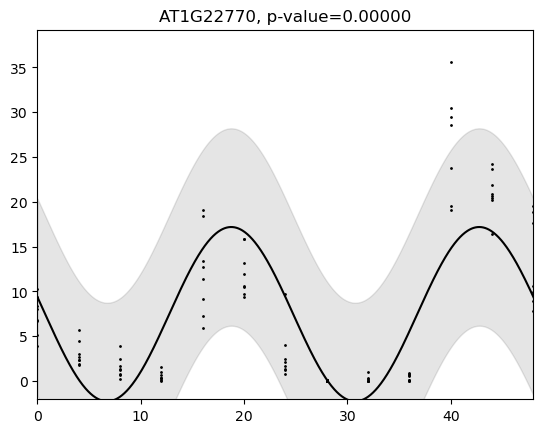

        test  period             p             q  amplitude  p(amplitude)  \
0  AT1G22770    24.0  4.944213e-22  4.944213e-22   9.720626  5.928245e-37   

   q(amplitude)                            CI(amplitude)  acrophase  \
0  5.928245e-37  [8.220438570590453, 11.220813319723316]   1.374443   

   p(acrophase)  q(acrophase)                            CI(acrophase)  \
0  1.189190e-74  1.189190e-74  [1.227078024883195, 1.5218070968167472]   

   acrophase[h]  
0     18.750016  


In [ ]:
plot_single_gene_cosinor("AT1G22770")

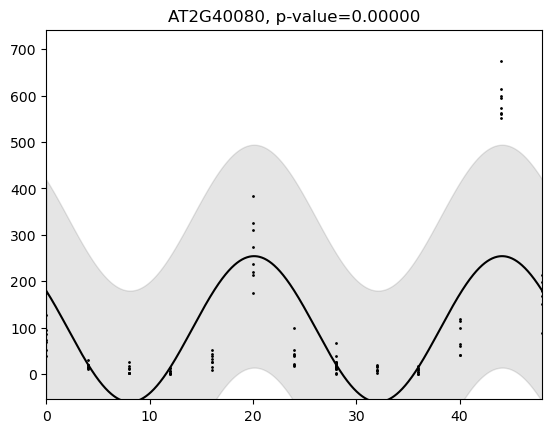

        test  period             p             q   amplitude  p(amplitude)  \
0  AT2G40080    24.0  1.378951e-14  1.378951e-14  157.197047  8.164542e-21   

   q(amplitude)                             CI(amplitude)  acrophase  \
0  8.164542e-21  [124.27152843557053, 190.12256622222276]   1.020565   

   p(acrophase)  q(acrophase)                            CI(acrophase)  \
0  4.422058e-24  4.422058e-24  [0.822944656388028, 1.2181846055415555]   

   acrophase[h]  
0      20.10173  


In [ ]:
plot_single_gene_cosinor("AT2G40080")

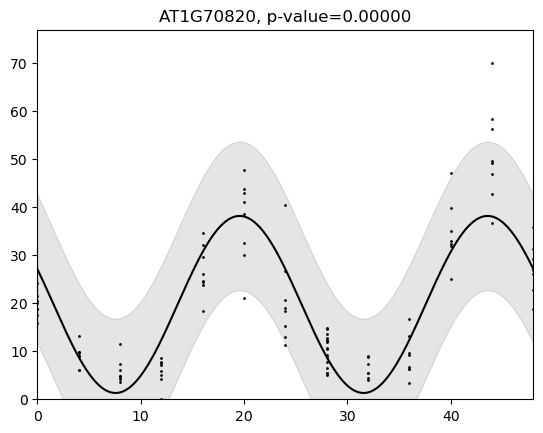

        test  period             p             q  amplitude  p(amplitude)  \
0  AT1G70820    24.0  4.245819e-31  4.245819e-31  18.437067  3.757758e-65   

   q(amplitude)                             CI(amplitude)  acrophase  \
0  3.757758e-65  [16.317127799668025, 20.557005618267258]     1.1623   

   p(acrophase)  q(acrophase)                            CI(acrophase)  \
0  1.282189e-97  1.282189e-97  [1.0536560582189847, 1.270944616013124]   

   acrophase[h]  
0      19.56034  


In [ ]:
plot_single_gene_cosinor("AT1G70820")

In [68]:
cosinor_results

,test,period,p,q,amplitude,p(amplitude),q(amplitude),CI(amplitude),acrophase,p(acrophase),q(acrophase),CI(acrophase),acrophase[h]
0,Actinomycetospora,24.0,5.379308e-12,2.766501e-11,0.383651,3.047744e-16,1.567411e-15,"[0.291630396333432, 0.47567254311538676]",-1.081838,6.856343e-18,2.468284e-17,"[-1.327897921329411, -0.8357787741086257]",4.132318
1,Actinoplanes,24.0,1.515468e-05,2.368931e-05,0.600663,6.900296e-07,1.080046e-06,"[0.36350704159520214, 0.8378191821456924]",-0.942379,6.815204e-06,9.813894e-06,"[-1.3528863034304124, -0.5318714846963519]",3.599622
2,Aetherobacter,24.0,5.978572e-09,1.956624e-08,0.345548,1.616941e-11,5.291806e-11,"[0.24501946864477123, 0.4460770634737622]",-1.109849,2.667294e-13,6.001412e-13,"[-1.4074145149139605, -0.8122838529378874]",4.239312
3,Agrobacterium,24.0,1.128190e-12,1.015371e-11,0.871859,2.181700e-17,1.963530e-16,"[0.6704358865537218, 1.073282661327319]",-0.984750,7.278634e-16,2.015622e-15,"[-1.2240430416224108, -0.7454577225670973]",3.761469
4,Aureimonas_A_501549,24.0,7.760615e-06,1.269919e-05,0.195302,2.911548e-07,4.764351e-07,"[0.12067146970843007, 0.2699316454512998]",-1.715619,4.324284e-20,2.594571e-19,"[-2.0819228279376887, -1.3493143714203895]",6.553180
5,Blastococcus,24.0,9.247049e-13,1.015371e-11,0.399117,1.590179e-17,1.908215e-16,"[0.3073072149039414, 0.4909267356202305]",-1.086556,1.733470e-19,7.803712e-19,"[-1.3224212990092707, -0.850691131094987]",4.150339
6,Brevundimonas,24.0,3.659592e-07,7.749723e-07,0.330625,4.997165e-09,1.058223e-08,"[0.2198016341469156, 0.44144802465301924]",-1.943269,3.057935e-33,2.752142e-32,"[-2.260336104381141, -1.6262023927273979]",7.422742
7,Caldora,24.0,1.174420e-11,5.284891e-11,0.310880,1.029738e-15,4.633819e-15,"[0.23493692534154612, 0.386823883046449]",-0.781499,2.514597e-09,4.114796e-09,"[-1.0384761442245374, -0.5245227742938336]",2.985108
8,Chryseobacterium_A_796612,24.0,6.802529e-03,7.420940e-03,0.336398,1.234972e-03,1.347242e-03,"[0.13231437725941173, 0.5404809990485882]",0.488410,1.055308e-01,1.117385e-01,"[-0.10300168951299726, 1.0798207898939212]",22.134413
9,Flavobacterium,24.0,2.125387e-03,2.391060e-03,3.225167,3.098560e-04,3.485880e-04,"[1.4726425179598766, 4.9776911621599345]",-1.167598,3.418771e-05,4.558362e-05,"[-1.719882393676773, -0.6153144360048817]",4.459897


In [ ]:
test_dataframe_cosinor = file_parser.generate_test_data(
    phase=0, n_components=1, name="test1", noise=0.5, replicates=3
)

In [13]:
test_dataframe_cosinor

,test,x,y
0,test1,0.0,0.469087
1,test1,2.0,1.011777
2,test1,4.0,0.954354
3,test1,6.0,0.061619
4,test1,8.0,0.287558
...,...,...,...
20,test1,40.0,-1.937984
21,test1,42.0,0.588971
22,test1,44.0,0.673770
23,test1,46.0,1.540919


In [23]:
gene_list = [
    "AT1G02920",
    "AT1G02930",
    "AT1G21110",
    "AT1G21120",
    "AT1G26380",
    "AT1G26410",
    "AT1G26420",
    "AT1G35230",
    "AT1G64170",
    "AT1G65500",
    "AT1G76930",
    "AT2G19190",
    "AT2G25470",
    "AT2G30750",
    "AT2G39200",
    "AT2G43620",
    "AT3G46280",
    "AT4G12490",
    "AT4G12500",
    "AT4G23140",
    "AT4G23220",
    "AT4G28420",
    "AT5G24110",
    "AT5G64120",
]

In [15]:
# Filter to genes in gene_list
filtered_circadian = cosinor_formatted_circadian_transcriptome[
    cosinor_formatted_circadian_transcriptome["test"].isin(gene_list)
].copy()

# Min-max normalize per gene
filtered_circadian["y"] = filtered_circadian.groupby("test")["y"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

filtered_circadian

,test,x,y
13189,AT1G02920,28.0,0.494270
13190,AT1G02920,32.0,0.464841
13191,AT1G02920,36.0,0.102176
13192,AT1G02920,44.0,0.089629
13193,AT1G02920,28.0,0.036142
...,...,...,...
1573846,AT5G64120,12.0,0.112786
1573847,AT5G64120,16.0,0.270429
1573848,AT5G64120,20.0,0.000000
1573849,AT5G64120,24.0,0.102916


In [24]:
# Filter to genes in gene_list
filtered_circadian_2 = cosinor_formatted_circadian_transcriptome_2[
    cosinor_formatted_circadian_transcriptome_2["test"].isin(gene_list)
].copy()

# Min-max normalize per gene
filtered_circadian_2["y"] = filtered_circadian_2.groupby("test")["y"].transform(
    lambda x: (x - x.min()) / (x.max() - x.min())
)

filtered_circadian_2

,test,x,y
11648,AT1G02920,0.0,0.033225
11649,AT1G02920,0.0,0.166822
11650,AT1G02920,0.0,0.017154
11651,AT1G02920,0.0,0.024670
11652,AT1G02920,0.0,0.011197
...,...,...,...
1460259,AT5G64120,48.0,0.220638
1460260,AT5G64120,48.0,0.032711
1460261,AT5G64120,0.0,0.004603
1460262,AT5G64120,16.0,0.584692


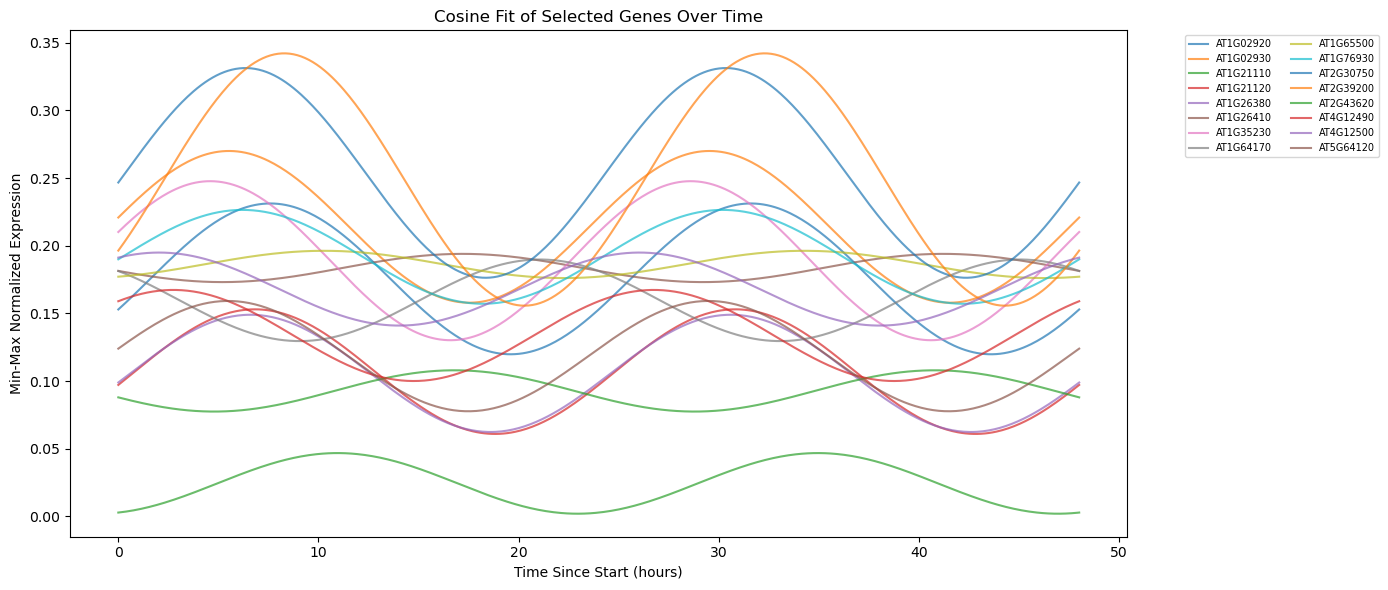

In [17]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def cosine_model(x, amplitude, phase, offset):
    return amplitude * np.cos(2 * np.pi * x / 24 - phase) + offset


fig, ax = plt.subplots(figsize=(14, 6))
x_fit = np.linspace(filtered_circadian["x"].min(), filtered_circadian["x"].max(), 500)

for gene, group in filtered_circadian.groupby("test"):
    x_data = group["x"].values
    y_data = group["y"].values
    try:
        popt, _ = curve_fit(
            cosine_model, x_data, y_data, p0=[0.5, 0, 0.5], maxfev=10000
        )
        ax.plot(x_fit, cosine_model(x_fit, *popt), label=gene, alpha=0.7)
    except RuntimeError:
        pass  # skip genes where fit doesn't converge

ax.set_xlabel("Time Since Start (hours)")
ax.set_ylabel("Min-Max Normalized Expression")
ax.set_title("Cosine Fit of Selected Genes Over Time")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

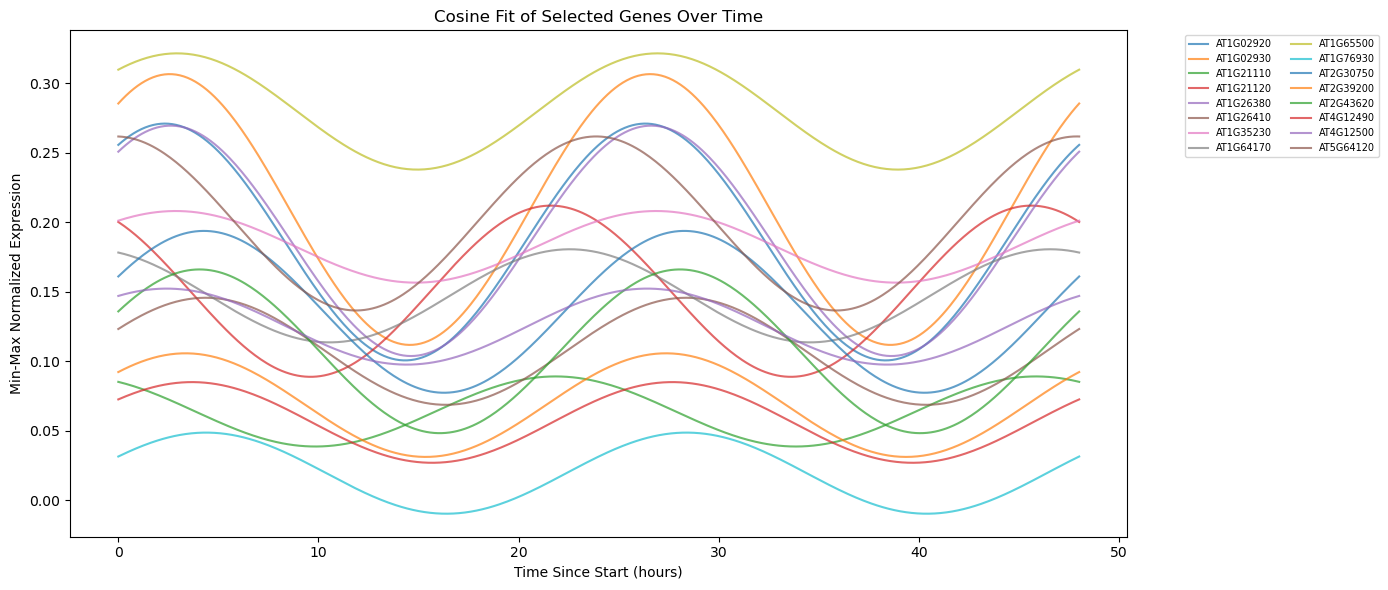

In [28]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def cosine_model(x, amplitude, phase, offset):
    return amplitude * np.cos(2 * np.pi * x / 24 - phase) + offset


fig, ax = plt.subplots(figsize=(14, 6))
x_fit = np.linspace(
    filtered_circadian_2["x"].min(), filtered_circadian_2["x"].max(), 500
)

for gene, group in filtered_circadian_2.groupby("test"):
    x_data = group["x"].values
    y_data = group["y"].values
    try:
        popt, _ = curve_fit(
            cosine_model, x_data, y_data, p0=[0.5, 0, 0.5], maxfev=10000
        )
        ax.plot(x_fit, cosine_model(x_fit, *popt), label=gene, alpha=0.7)
    except RuntimeError:
        pass  # skip genes where fit doesn't converge

ax.set_xlabel("Time Since Start (hours)")
ax.set_ylabel("Min-Max Normalized Expression")
ax.set_title("Cosine Fit of Selected Genes Over Time")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

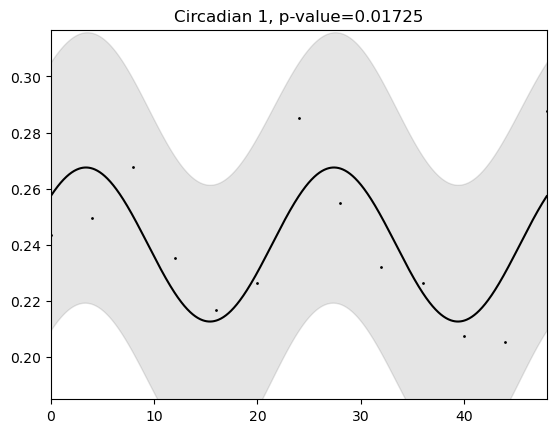

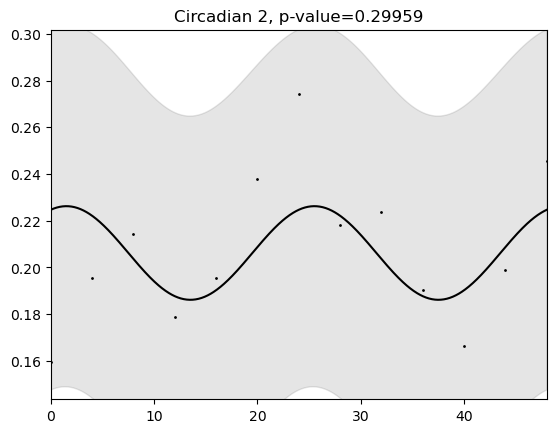

,test,period,p,q,amplitude,p(amplitude),q(amplitude),CI(amplitude),acrophase,p(acrophase),q(acrophase),CI(acrophase),acrophase[h]
0,Circadian 1,24.0,0.017252,0.034504,0.027427,0.000415,0.000831,"[0.012199539871653032, 0.042654565189058656]",-0.892299,0.001383,0.002767,"[-1.4391477270250141, -0.34544976665292504]",3.408330
1,Circadian 2,24.0,0.299592,0.299592,0.020037,0.099162,0.099162,"[-0.0037794778319397287, 0.04385268990504112]",-0.397086,0.533437,0.533437,"[-1.6467876098721175, 0.8526152131270934]",1.516758


In [8]:
def build_defense_average_timecourse(
    transcriptome_df, metadata_df, defense_genes, label
):
    defense_genes_present = transcriptome_df.columns.intersection(defense_genes)
    if len(defense_genes_present) == 0:
        raise ValueError(
            f"No defense genes from the identified list were found for {label}."
        )

    normalized_expression = transcriptome_df.loc[:, defense_genes_present].copy()
    normalized_expression = normalized_expression.apply(
        lambda column: (
            (column - column.min()) / (column.max() - column.min())
            if column.max() > column.min()
            else pd.Series(0.0, index=column.index)
        )
    )

    averaged_samples = normalized_expression.mean(axis=1).rename(
        "mean_normalized_defense_expression"
    )
    averaged_samples = averaged_samples.to_frame().merge(
        metadata_df[["timepoint", "Time Since Start"]],
        left_index=True,
        right_index=True,
    )

    averaged_by_timepoint = (
        averaged_samples.groupby(["timepoint", "Time Since Start"], as_index=False)[
            "mean_normalized_defense_expression"
        ]
        .mean()
        .sort_values("Time Since Start")
    )
    averaged_by_timepoint["test"] = label
    averaged_by_timepoint = averaged_by_timepoint.rename(
        columns={
            "Time Since Start": "x",
            "mean_normalized_defense_expression": "y",
        }
    )

    return averaged_by_timepoint[["test", "x", "y"]]


averaged_defense_timecourse_1 = build_defense_average_timecourse(
    circadian_transcriptome, circadian_metadata, full_defense_gene_list, "Circadian 1"
)
averaged_defense_timecourse_2 = build_defense_average_timecourse(
    circadian_transcriptome_2,
    circadian_metadata_2,
    full_defense_gene_list,
    "Circadian 2",
)

combined_defense_timecourses = pd.concat(
    [averaged_defense_timecourse_1, averaged_defense_timecourse_2],
    ignore_index=True,
)
combined_defense_timecourses

averaged_defense_cosinor_results = cosinor1.fit_group(
    combined_defense_timecourses, period=[24], plot_on=True
)
averaged_defense_cosinor_results